# Score-Based Models

In [1]:
import torch
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os
import shutil

input_path = "/kaggle/input/mnist-dataset"
writable_root = "./data"
raw_folder = os.path.join(writable_root, "MNIST", "raw")

os.makedirs(raw_folder, exist_ok=True)

files_to_copy = [
    "train-images-idx3-ubyte", "train-labels-idx1-ubyte",
    "t10k-images-idx3-ubyte", "t10k-labels-idx1-ubyte"
]

print("Copying files to writable directory...")
for file_name in files_to_copy:
    src = os.path.join(input_path, file_name)
    dst = os.path.join(raw_folder, file_name)
    
    if os.path.exists(src):
        if os.path.isdir(src):
            contents = os.listdir(src)
            if contents:
                src = os.path.join(src, contents[0])
        
        if not os.path.exists(dst):
            shutil.copy(src, dst)
            print(f"Copied {file_name}")
        else:
            print(f"Skipped {file_name} (already exists)")
            
    else:
        alt_src = os.path.join(input_path, file_name.replace('-', '.'))
        if os.path.exists(alt_src):
             shutil.copy(alt_src, dst)
             print(f"Copied {file_name} (from alternative name)")
        else:
             print(f"Warning: {file_name} not found.")


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])

BATCH_SIZE = 64 

train_dataset = datasets.MNIST(root=writable_root, train=True, download=False, transform=transform)
test_dataset = datasets.MNIST(root=writable_root, train=False, download=False, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"\nDataset Loaded Successfully.")
print(f"Train size: {len(train_dataset)}, Test size: {len(test_dataset)}")
print(f"Data Range: [{train_dataset[0][0].min():.2f}, {train_dataset[0][0].max():.2f}]")


SIGMA_BEGIN = 30.0
SIGMA_END = 0.01
NUM_LEVELS = 10

sigmas_np = np.geomspace(start=SIGMA_BEGIN, stop=SIGMA_END, num=NUM_LEVELS)
sigmas = torch.tensor(sigmas_np).float()

print("\nGenerated Noise Levels (Sigmas):")
print(sigmas)


Copying files to writable directory...
Copied train-images-idx3-ubyte
Copied train-labels-idx1-ubyte
Copied t10k-images-idx3-ubyte
Copied t10k-labels-idx1-ubyte

Dataset Loaded Successfully.
Train size: 60000, Test size: 10000
Data Range: [-1.00, 1.00]

Generated Noise Levels (Sigmas):
tensor([3.0000e+01, 1.2325e+01, 5.0632e+00, 2.0801e+00, 8.5454e-01, 3.5106e-01,
        1.4422e-01, 5.9251e-02, 2.4341e-02, 1.0000e-02])


In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import sys
from torchinfo import summary


class GaussianFourierProjection(nn.Module):

    def __init__(self, embed_dim=256, scale=30.0):
        super().__init__()

        self.W = nn.Parameter(torch.randn(embed_dim // 2) * scale, requires_grad=False)

    def forward(self, x):
        x_proj = x[:, None] * self.W[None, :] * 2 * np.pi
        return torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)

class FiLM(nn.Module):

    def __init__(self, in_channels, emb_dim):
        super().__init__()
        self.group_norm = nn.GroupNorm(num_groups=32, num_channels=in_channels)
        self.proj = nn.Linear(emb_dim, in_channels * 2)

    def forward(self, x, emb):

        stats = self.proj(emb)    
        stats = stats[:, :, None, None]
        scale, shift = stats.chunk(2, dim=1)
        
        x = self.group_norm(x)
        

        x = x * (1 + scale) + shift
        return x

class AdaptiveResBlock(nn.Module):

    def __init__(self, in_channels, out_channels, emb_dim):
        super().__init__()
        
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)
        self.film1 = FiLM(out_channels, emb_dim)
        self.act = nn.SiLU()
        
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)
        self.film2 = FiLM(out_channels, emb_dim)
        
        if in_channels != out_channels:
            self.shortcut = nn.Conv2d(in_channels, out_channels, 1)
        else:
            self.shortcut = nn.Identity()

    def forward(self, x, emb):
        h = self.conv1(x)
        h = self.film1(h, emb) 
        h = self.act(h)
        
        h = self.conv2(h)
        h = self.film2(h, emb)
        h = self.act(h)
        
        return h + self.shortcut(x)

class ScoreNet(nn.Module):

    def __init__(self):
        super().__init__()
        

        self.embed = nn.Sequential(
            GaussianFourierProjection(embed_dim=256),
            nn.Linear(256, 256),
            nn.SiLU(),
            nn.Linear(256, 256),
        )
        
        self.input_conv = nn.Conv2d(1, 64, 3, padding=1)
        

        self.enc1 = AdaptiveResBlock(64, 64, 256)
        self.pool1 = nn.AvgPool2d(2)
        
        self.enc2 = AdaptiveResBlock(64, 128, 256)
        self.pool2 = nn.AvgPool2d(2)
        
        self.enc3 = AdaptiveResBlock(128, 256, 256)
        

        self.dec1 = AdaptiveResBlock(256 + 128, 128, 256)
        
        self.dec2 = AdaptiveResBlock(128 + 64, 64, 256)
        
        self.output_conv = nn.Conv2d(64, 1, 3, padding=1)

    def forward(self, x, sigma):

        emb = self.embed(sigma)
        
        h = self.input_conv(x)
        
        h1 = self.enc1(h, emb)    
        h_down1 = self.pool1(h1)  
        
        h2 = self.enc2(h_down1, emb) 
        h_down2 = self.pool2(h2)  
        
        h3 = self.enc3(h_down2, emb) 

        h_up1 = F.interpolate(h3, scale_factor=2, mode='nearest')
        h_cat1 = torch.cat([h_up1, h2], dim=1) 
        h4 = self.dec1(h_cat1, emb)          
        
        h_up2 = F.interpolate(h4, scale_factor=2, mode='nearest')
        h_cat2 = torch.cat([h_up2, h1], dim=1) 
        h5 = self.dec2(h_cat2, emb)           
        
        out = self.output_conv(h5)
        
        out = out / sigma[:, None, None, None]
        
        return out



model = ScoreNet()

batch_size = 4
dummy_x = torch.randn(batch_size, 1, 28, 28)
dummy_sigma = torch.randn(batch_size)

print("-" * 65)
print("ScoreNet Model Summary")
print("-" * 65)
    
summary(model, 
        input_data=[dummy_x, dummy_sigma], 
        col_names=["input_size", "output_size", "num_params", "kernel_size", "mult_adds"],
        verbose=1)

-----------------------------------------------------------------
ScoreNet Model Summary
-----------------------------------------------------------------
Layer (type:depth-idx)                        Input Shape               Output Shape              Param #                   Kernel Shape              Mult-Adds
ScoreNet                                      [4, 1, 28, 28]            [4, 1, 28, 28]            --                        --                        --
├─Sequential: 1-1                             [4]                       [4, 256]                  --                        --                        --
│    └─GaussianFourierProjection: 2-1         [4]                       [4, 256]                  (128)                     --                        --
│    └─Linear: 2-2                            [4, 256]                  [4, 256]                  65,792                    --                        263,168
│    └─SiLU: 2-3                              [4, 256]              

Layer (type:depth-idx)                        Input Shape               Output Shape              Param #                   Kernel Shape              Mult-Adds
ScoreNet                                      [4, 1, 28, 28]            [4, 1, 28, 28]            --                        --                        --
├─Sequential: 1-1                             [4]                       [4, 256]                  --                        --                        --
│    └─GaussianFourierProjection: 2-1         [4]                       [4, 256]                  (128)                     --                        --
│    └─Linear: 2-2                            [4, 256]                  [4, 256]                  65,792                    --                        263,168
│    └─SiLU: 2-3                              [4, 256]                  [4, 256]                  --                        --                        --
│    └─Linear: 2-4                            [4, 256]                

<>:149: SyntaxWarning: invalid escape sequence '\s'
<>:151: SyntaxWarning: invalid escape sequence '\s'
<>:149: SyntaxWarning: invalid escape sequence '\s'
<>:151: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_55/4106897383.py:149: SyntaxWarning: invalid escape sequence '\s'
  ax.set_title(f"Final ($\sigma$={sigmas[-1]:.2f})")
/tmp/ipykernel_55/4106897383.py:151: SyntaxWarning: invalid escape sequence '\s'
  ax.set_title(f"$\sigma$={sigmas[hist_idx-1]:.2f}") # history[k] corresponds to after sigma[k-1]


Starting Training...


Epoch 30/30: 100%|██████████| 938/938 [00:45<00:00, 20.64it/s, loss=24]  


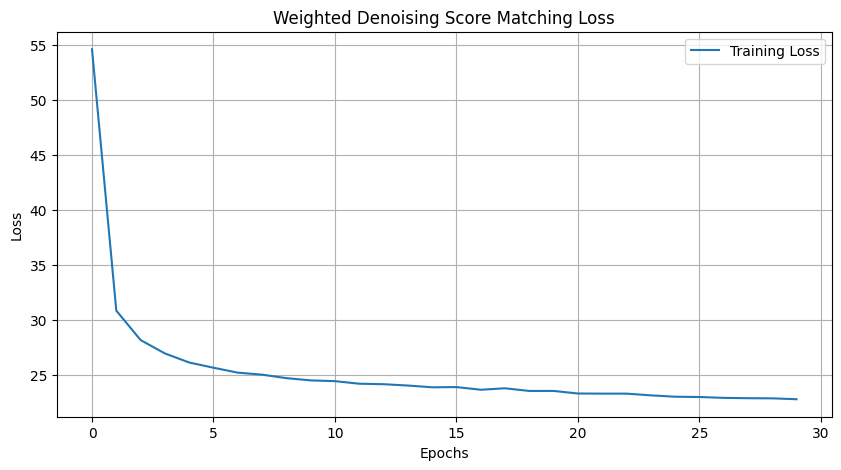

Generating Samples...


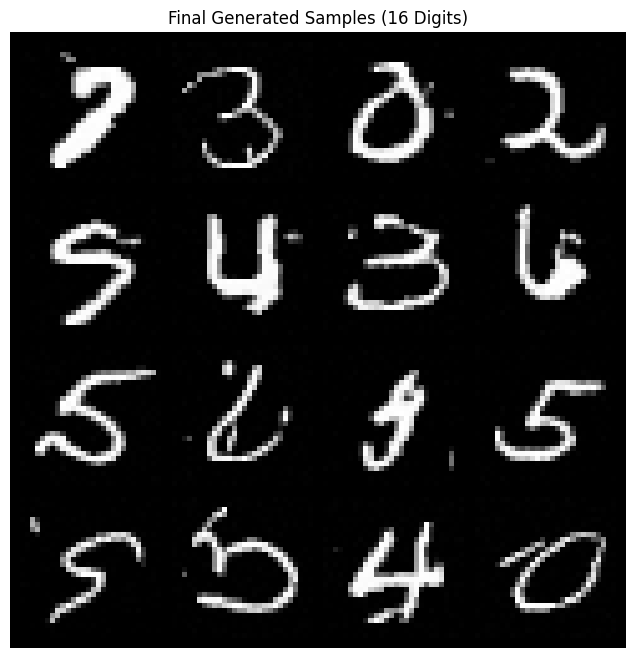

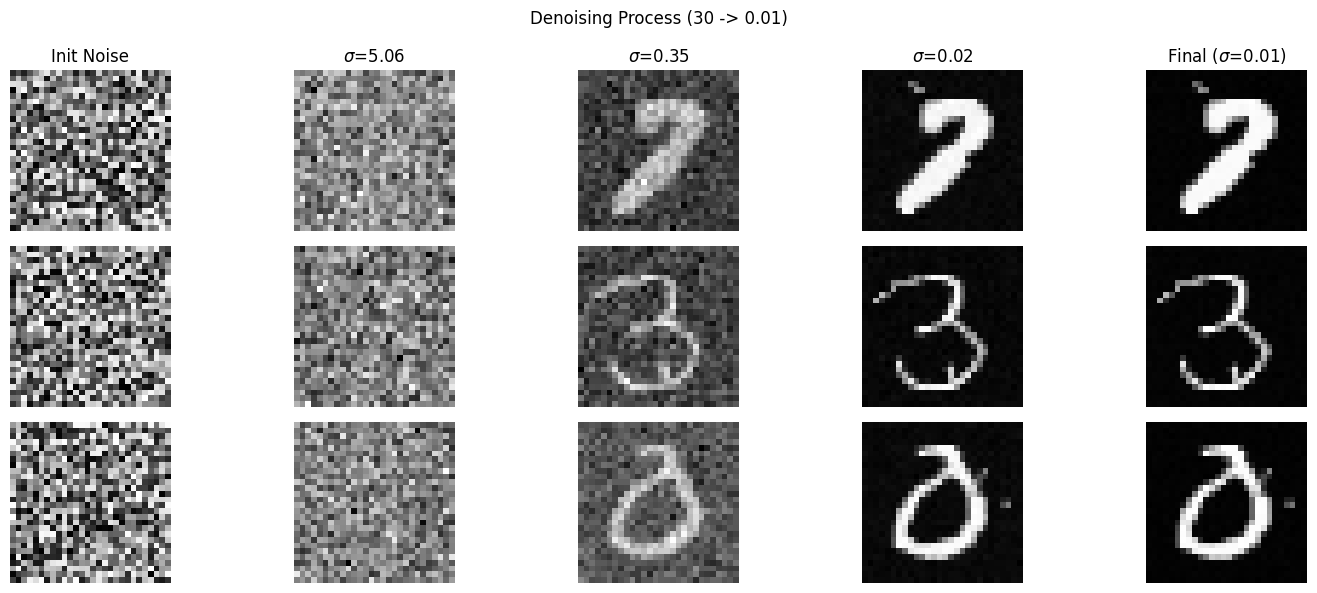

In [9]:
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import torchvision

SIGMA_BEGIN = 30
SIGMA_END = 0.01
NUM_LEVELS = 10
BATCH_SIZE = 64
LEARNING_RATE = 2e-4
EPOCHS = 30
LANGEVIN_STEPS = 150  
STEP_LR = 2e-5       

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

sigmas_np = np.geomspace(SIGMA_BEGIN, SIGMA_END, NUM_LEVELS)
sigmas = torch.tensor(sigmas_np).float().to(DEVICE)

model = ScoreNet().to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

def computed_weighted_dsm_loss(model, x, sigmas):

    indices = torch.randint(0, len(sigmas), (x.shape[0],), device=x.device)
    used_sigmas = sigmas[indices].view(x.shape[0], 1, 1, 1)
    
    z = torch.randn_like(x)
    x_perturbed = x + used_sigmas * z
    

    score = model(x_perturbed, used_sigmas.view(-1))
    
    target = -z / used_sigmas
    
    loss = 0.5 * ((used_sigmas * score + z) ** 2).sum() / x.shape[0]
    return loss

print("Starting Training...")
losses = []

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    
    for x, _ in pbar:
        x = x.to(DEVICE)
        
        optimizer.zero_grad()
        loss = computed_weighted_dsm_loss(model, x, sigmas)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        pbar.set_postfix(loss=loss.item())
    
    avg_loss = epoch_loss / len(train_loader)
    losses.append(avg_loss)

plt.figure(figsize=(10, 5))
plt.plot(losses, label='Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Weighted Denoising Score Matching Loss')
plt.legend()
plt.grid(True)
plt.show()

def annealed_langevin_dynamics(model, sigmas, n_samples=16, epsilon=2e-5, T=150):
    model.eval()
    x = torch.rand(n_samples, 1, 28, 28).to(DEVICE) * 2 - 1
    
    history = [x.detach().cpu()]
    
    with torch.no_grad():
        for i, sigma in enumerate(sigmas):

            sigma_L = sigmas[-1]
            alpha = epsilon * (sigma / sigma_L) ** 2
            
            for t in range(T):
                z = torch.randn_like(x)
                # Predict score
                score = model(x, sigma.expand(n_samples))
                # Update x
                x = x + 0.5 * alpha * score + torch.sqrt(alpha) * z
            
            history.append(x.detach().cpu())
            
    return x, history

print("Generating Samples...")
final_samples, history = annealed_langevin_dynamics(
    model, sigmas, n_samples=16, epsilon=STEP_LR, T=LANGEVIN_STEPS
)

grid_img = torchvision.utils.make_grid(final_samples.cpu(), nrow=4, normalize=True, value_range=(-1, 1))
plt.figure(figsize=(8, 8))
plt.title("Final Generated Samples (16 Digits)")
plt.imshow(grid_img.permute(1, 2, 0), cmap='gray')
plt.axis('off')
plt.show()


indices_to_show = [0, 3, 6, 9, 10] 
num_samples_to_track = 3

fig, axes = plt.subplots(num_samples_to_track, len(indices_to_show), figsize=(15, 6))
fig.suptitle(f"Denoising Process ({SIGMA_BEGIN} -> {SIGMA_END})")

for i in range(num_samples_to_track):
    for j, hist_idx in enumerate(indices_to_show):
        sample = history[hist_idx][i]
        ax = axes[i, j]
        ax.imshow(sample.squeeze(), cmap='gray')
        
        # Labeling
        if i == 0:
            if hist_idx == 0:
                ax.set_title("Init Noise")
            elif hist_idx == 10:
                ax.set_title(f"Final ($\sigma$={sigmas[-1]:.2f})")
            else:
                ax.set_title(f"$\sigma$={sigmas[hist_idx-1]:.2f}") 
        ax.axis('off')

plt.tight_layout()
plt.show()

Estimating optimal Sigma Begin from data...
Estimated SIGMA_BEGIN: 28.8241

MODEL SUMMARY
Layer (type:depth-idx)                        Input Shape               Output Shape              Param #                   Kernel Shape
ConditionalScoreNet                           [1, 1, 28, 28]            [1, 1, 28, 28]            --                        --
├─Sequential: 1-1                             [1]                       [1, 256]                  --                        --
│    └─GaussianFourierProjection: 2-1         [1]                       [1, 256]                  (128)                     --
│    └─Linear: 2-2                            [1, 256]                  [1, 256]                  65,792                    --
│    └─SiLU: 2-3                              [1, 256]                  [1, 256]                  --                        --
│    └─Linear: 2-4                            [1, 256]                  [1, 256]                  65,792                    --
├─Embedding

Epoch 30/30: 100%|██████████| 938/938 [00:47<00:00, 19.84it/s, loss=24.4]


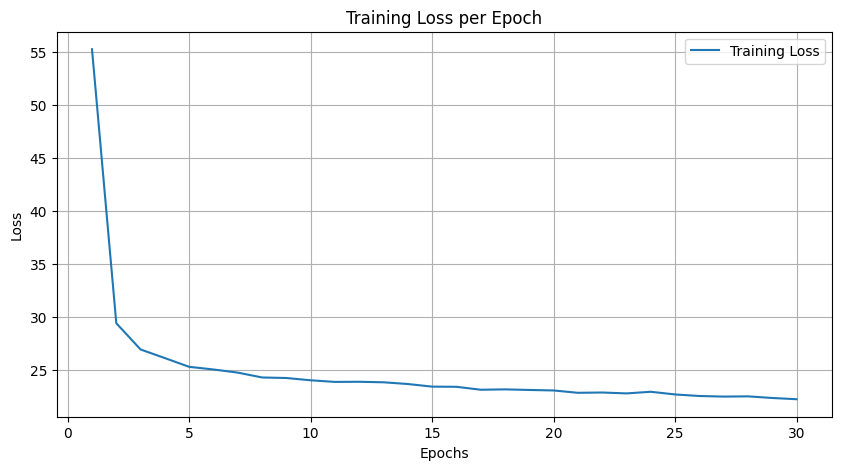


Generating samples for Digit 5...


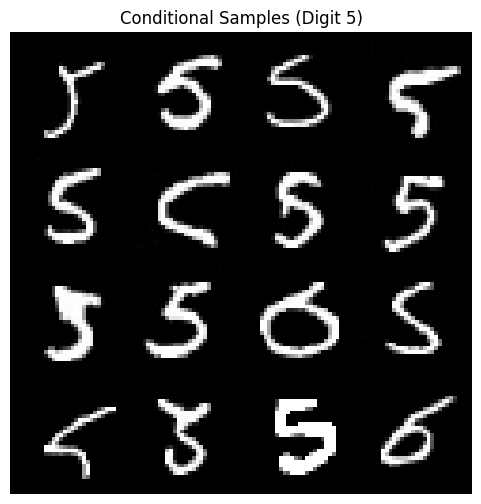

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import sys

from torchinfo import summary



DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 64
LR = 2e-4
EPOCHS = 30
SIGMA_END = 0.01
LANGEVIN_STEPS = 150
STEP_LR = 2e-5
EMA_DECAY = 0.999
NUM_LEVELS = 50 

    

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])

try:
    train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
except:
    print("Loading from input directory...")
    train_dataset = torchvision.datasets.MNIST(root='/kaggle/input/mnist-dataset', train=True, download=False, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

def estimate_sigma_max(data_loader):
    print("Estimating optimal Sigma Begin from data...")
    x, _ = next(iter(data_loader))
    x = x.to(DEVICE)
    x_flat = x.view(x.shape[0], -1)
    dist_matrix = torch.cdist(x_flat, x_flat, p=2)
    return dist_matrix.max().item()

SIGMA_BEGIN = estimate_sigma_max(train_loader)
print(f"Estimated SIGMA_BEGIN: {SIGMA_BEGIN:.4f}")

sigmas_np = np.geomspace(SIGMA_BEGIN, SIGMA_END, NUM_LEVELS)
sigmas = torch.tensor(sigmas_np).float().to(DEVICE)


class GaussianFourierProjection(nn.Module):
    def __init__(self, embed_dim=256, scale=30.0):
        super().__init__()
        self.W = nn.Parameter(torch.randn(embed_dim // 2) * scale, requires_grad=False)

    def forward(self, x):
        x_proj = x[:, None] * self.W[None, :] * 2 * np.pi
        return torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)

class FiLM(nn.Module):
    def __init__(self, in_channels, emb_dim):
        super().__init__()
        self.group_norm = nn.GroupNorm(num_groups=32, num_channels=in_channels)
        self.proj = nn.Linear(emb_dim, in_channels * 2)

    def forward(self, x, emb):
        stats = self.proj(emb)
        stats = stats[:, :, None, None]
        scale, shift = stats.chunk(2, dim=1)
        x = self.group_norm(x)
        x = x * (1 + scale) + shift
        return x

class AdaptiveResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, emb_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)
        self.film1 = FiLM(out_channels, emb_dim)
        self.act = nn.SiLU() 
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)
        self.film2 = FiLM(out_channels, emb_dim)
        
        if in_channels != out_channels:
            self.shortcut = nn.Conv2d(in_channels, out_channels, 1)
        else:
            self.shortcut = nn.Identity()

    def forward(self, x, emb):
        h = self.conv1(x)
        h = self.film1(h, emb)
        h = self.act(h)
        h = self.conv2(h)
        h = self.film2(h, emb)
        h = self.act(h)
        return h + self.shortcut(x)

class ConditionalScoreNet(nn.Module):
    def __init__(self, num_classes=10, embed_dim=256):
        super().__init__()
        self.sigma_embed = nn.Sequential(
            GaussianFourierProjection(embed_dim=embed_dim),
            nn.Linear(embed_dim, embed_dim),
            nn.SiLU(),
            nn.Linear(embed_dim, embed_dim),
        )
        self.class_embed = nn.Embedding(num_classes, embed_dim)
        
        self.input_conv = nn.Conv2d(1, 64, 3, padding=1)
        self.enc1 = AdaptiveResBlock(64, 64, embed_dim)
        self.pool1 = nn.AvgPool2d(2)
        self.enc2 = AdaptiveResBlock(64, 128, embed_dim)
        self.pool2 = nn.AvgPool2d(2)
        self.enc3 = AdaptiveResBlock(128, 256, embed_dim)
        
        self.dec1 = AdaptiveResBlock(256 + 128, 128, embed_dim)
        self.dec2 = AdaptiveResBlock(128 + 64, 64, embed_dim)
        self.output_conv = nn.Conv2d(64, 1, 3, padding=1)

    def forward(self, x, sigma, y):
        emb = self.sigma_embed(sigma) + self.class_embed(y)
        
        h = self.input_conv(x)
        h1 = self.enc1(h, emb)
        h_down1 = self.pool1(h1)
        h2 = self.enc2(h_down1, emb)
        h_down2 = self.pool2(h2)
        h3 = self.enc3(h_down2, emb)
        
        h_up1 = F.interpolate(h3, scale_factor=2, mode='nearest')
        h_dec1 = self.dec1(torch.cat([h_up1, h2], dim=1), emb)
        h_up2 = F.interpolate(h_dec1, scale_factor=2, mode='nearest')
        h_dec2 = self.dec2(torch.cat([h_up2, h1], dim=1), emb)
        
        out = self.output_conv(h_dec2)
        return out / sigma[:, None, None, None]


class EMA:
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = {}
        self.original = {}
        for name, param in model.named_parameters():
            if param.requires_grad:
                self.shadow[name] = param.data.clone()

    def update(self, model):
        for name, param in model.named_parameters():
            if param.requires_grad:
                new_avg = (1.0 - self.decay) * param.data + self.decay * self.shadow[name]
                self.shadow[name] = new_avg.clone()

    def apply_shadow(self, model):
        for name, param in model.named_parameters():
            if param.requires_grad:
                self.original[name] = param.data.clone()
                param.data = self.shadow[name]

    def restore(self, model):
        for name, param in model.named_parameters():
            if param.requires_grad:
                param.data = self.original[name]
        self.original = {}

def conditional_dsm_loss(model, x, y, sigmas):
    indices = torch.randint(0, len(sigmas), (x.shape[0],), device=x.device)
    used_sigmas = sigmas[indices]
    z = torch.randn_like(x)
    x_perturbed = x + used_sigmas.view(-1, 1, 1, 1) * z
    score = model(x_perturbed, used_sigmas, y)
    loss = 0.5 * ((used_sigmas.view(-1, 1, 1, 1) * score + z) ** 2).sum() / x.shape[0]
    return loss

model = ConditionalScoreNet().to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LR)
ema = EMA(model, decay=EMA_DECAY)


print("\n" + "="*30)
print("MODEL SUMMARY")
print("="*30)

batch_size_summary = 1
dummy_x = torch.randn(batch_size_summary, 1, 28, 28).to(DEVICE)
dummy_sigma = torch.randn(batch_size_summary).to(DEVICE)
dummy_y = torch.randint(0, 10, (batch_size_summary,)).to(DEVICE)

summary(model, 
        input_data=[dummy_x, dummy_sigma, dummy_y],
        col_names=["input_size", "output_size", "num_params", "kernel_size"],
        verbose=1)
print("="*30 + "\n")


print("Starting Training...")
losses = []

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    
    for x, y in pbar:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        loss = conditional_dsm_loss(model, x, y, sigmas)
        loss.backward()
        optimizer.step()
        ema.update(model)
        epoch_loss += loss.item()
        pbar.set_postfix(loss=loss.item())
    losses.append(epoch_loss / len(train_loader))

plt.figure(figsize=(10, 5))
plt.plot(range(1, EPOCHS + 1), losses, label='Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss per Epoch')
plt.grid(True)
plt.legend()
plt.show()

def generate_conditional_samples(model, ema, sigmas, digit_class=0):
    print(f"\nGenerating samples for Digit {digit_class}...")
    ema.apply_shadow(model)
    model.eval()
    
    y = torch.full((16,), digit_class, dtype=torch.long).to(DEVICE)
    x = torch.rand(16, 1, 28, 28).to(DEVICE) * 2 - 1
    
    with torch.no_grad():
        for sigma in sigmas:
            alpha = STEP_LR * (sigma / sigmas[-1]) ** 2
            for t in range(LANGEVIN_STEPS):
                z = torch.randn_like(x)
                score = model(x, sigma.expand(x.shape[0]), y)
                x = x + 0.5 * alpha * score + torch.sqrt(alpha) * z
    
    ema.restore(model)
    return x

samples = generate_conditional_samples(model, ema, sigmas, digit_class=5)
grid = torchvision.utils.make_grid(samples.cpu(), nrow=4, normalize=True, value_range=(-1, 1))
plt.figure(figsize=(6, 6))
plt.title("Conditional Samples (Digit 5)")
plt.imshow(grid.permute(1, 2, 0), cmap='gray')
plt.axis('off')
plt.show()


Generating grid for digits 0-9...


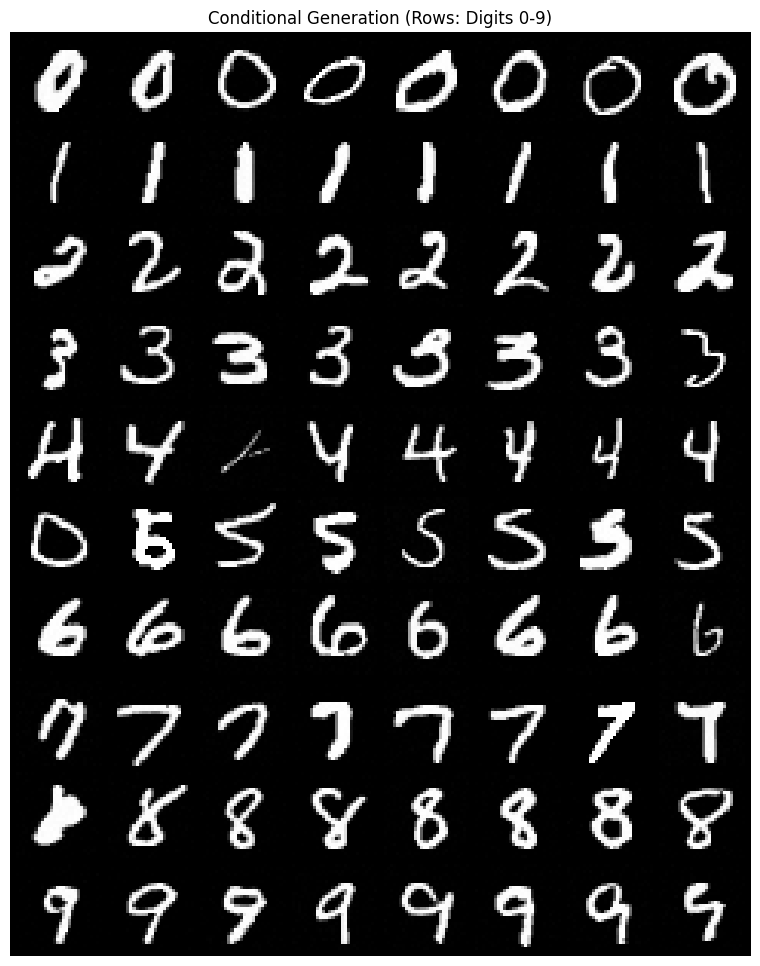

In [4]:
def generate_digit_grid(model, ema, sigmas):
    print("\nGenerating grid for digits 0-9...")
    ema.apply_shadow(model)
    model.eval()
    
    all_samples = []
    
    for digit in range(10):
        n_samples_per_digit = 8 
        y = torch.full((n_samples_per_digit,), digit, dtype=torch.long).to(DEVICE)
        x = torch.rand(n_samples_per_digit, 1, 28, 28).to(DEVICE) * 2 - 1
        
        with torch.no_grad():
            for sigma in sigmas:
                alpha = STEP_LR * (sigma / sigmas[-1]) ** 2
                for t in range(LANGEVIN_STEPS):
                    z = torch.randn_like(x)
                    score = model(x, sigma.expand(x.shape[0]), y)
                    x = x + 0.5 * alpha * score + torch.sqrt(alpha) * z
        
        all_samples.append(x.cpu())

    ema.restore(model)
    return torch.cat(all_samples, dim=0)

grid_samples = generate_digit_grid(model, ema, sigmas)


final_grid = torchvision.utils.make_grid(grid_samples, nrow=8, normalize=True, value_range=(-1, 1), padding=2)

plt.figure(figsize=(10, 12))
plt.title("Conditional Generation (Rows: Digits 0-9)")
plt.imshow(final_grid.permute(1, 2, 0), cmap='gray')
plt.axis('off')
plt.show()